In [9]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets.csv


In [10]:
!pip install nltk

In [11]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
df = pd.read_csv('customer_support_tickets.csv')

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [14]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [15]:
df = df[['Ticket Description','Ticket Type']]

In [16]:
df.columns = ['text','category']

In [17]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [18]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['category']

In [19]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred = model.predict(X_test)

In [22]:
acc = accuracy_score(y_test,y_pred)

print("Accuracy:",acc)

Accuracy: 0.19834710743801653


In [23]:
print(classification_report(y_test,y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.14      0.16       357
Cancellation request       0.18      0.20      0.19       327
     Product inquiry       0.19      0.18      0.18       316
      Refund request       0.21      0.24      0.22       345
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



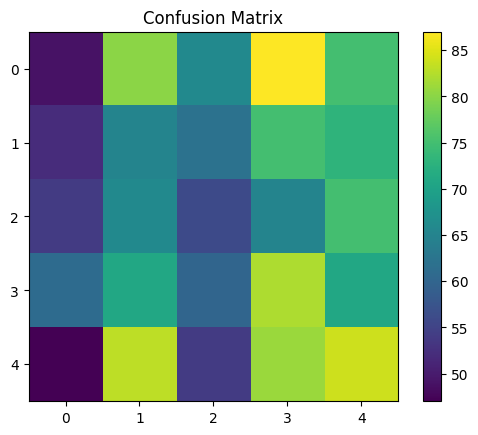

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.show()

In [25]:
def priority(text):

    text = text.lower()

    high_words = [
        'urgent',
        'failed',
        'error',
        'down',
        'critical'
    ]

    medium_words = [
        'delay',
        'slow',
        'issue'
    ]

    for word in high_words:
        if word in text:
            return 'High'

    for word in medium_words:
        if word in text:
            return 'Medium'

    return 'Low'

In [26]:
df['Priority'] = df['text'].apply(priority)

df[['text','Priority']].head()

,text,Priority
0,I'm having an issue with the {product_purchase...,Medium
1,I'm having an issue with the {product_purchase...,Medium
2,I'm facing a problem with my {product_purchase...,Low
3,I'm having an issue with the {product_purchase...,Medium
4,I'm having an issue with the {product_purchase...,Medium


In [28]:
ticket = """
Unable to login into account.
System shows error and access is blocked.
"""

clean = clean_text(ticket)


In [29]:
ticket = """
Unable to login into account.
System shows error and access is blocked.
"""

clean = clean_text(ticket)

vector = vectorizer.transform([clean])

prediction = model.predict(vector)

print("Predicted Category:", prediction[0])

Predicted Category: Cancellation request


In [30]:
print("Priority:", priority(ticket))

Priority: High


In [31]:
print("Ticket:")
print(ticket)

print("\nCategory:", prediction[0])

print("Priority:", priority(ticket))

Ticket:

Unable to login into account.
System shows error and access is blocked.


Category: Cancellation request
Priority: High


Business Impact

The system automatically classifies support tickets into categories such as Billing, Technical Issues, and Account Management.

It also assigns a priority level (High, Medium, Low) based on ticket content.

Benefits:
- Faster ticket routing
- Reduced manual effort
- Improved response times
- Better customer satisfaction

Conclusion

A machine learning-based support ticket classification system was developed using NLP techniques.

The model uses TF-IDF vectorization and Logistic Regression to classify support tickets.

Priority levels are assigned using keyword-based rules.

This solution can help businesses automate support operations and improve efficiency.